# Subjecting codes of various dimensionality to global rotations

**A TSIM Implementation of "A fault-tolerant neutral-atom architecture for universal quantum computation"**

*Reproduction of Figure 4a from Bluvstein, D. et al. (2025) using TSIM *

### At a Glance:
This tutorial will guide practitioner to reproduce experiments of this paper in regard to the logical X expectation value vs global Z-rotation angle φ
for three code configurations:
  1. Unentangled physical qubits (analyzed as 3D code)
  2. 2D color code (Steane [[7,1,3]])
  3. 3D color code (Reed-Muller [[15,1,3]])

The key feature to observe: the 3D Reed-Muller code shows plateaus at multiples of 45°
corresponding to its transversal T gate — not seen in the 2D code.

## Rationale behind the article

The Steane code can do transversal gates — apply a gate qubit-by-qubit across the 7 physical qubits without spreading errors. But there's a fundamental obstacle:

### The Eastin-Knill Theorem
> No quantum error-correcting code can implement a universal gate set using only transversal operations.

This means the Steane code's transversal gates (H, S, CNOT) are powerful but not enough to do arbitrary quantum computations. You're missing something.

### What's Missing: The T Gate
A universal gate set needs at least:
H  +  T  =  universal single-qubit rotations
The T gate is a 45° rotation around the Z axis:

```
T = [1    0  ]
    [0   e^(iπ/4)]
```

It's a non-Clifford gate — it lives outside the "safe" Clifford group that stabilizer codes handle naturally. And by Eastin-Knill, you can't get it transversally from the Steane code.

### The Solovay-Kitaev Theorem
> Any single-qubit rotation (any point on the Bloch sphere) can be approximated to exponential precision using only H and T gates.

Concretely, if you want precision ε, you need only O(log^c(1/ε)) gates — a very efficient approximation. This means:
H and T gates alone = universal quantum computation
So the whole problem reduces to: how do you implement a fault-tolerant T gate?

### The Solution: 3D Codes + Teleportation
This is where the paper's key insight comes in. They use a hierarchy of codes:
- 2D Color Codes = Steane Code
The familiar 7-qubit code = Transversal gates: H, S, CNOT (the Clifford group). but no transversal T.
- 3D Color Codes = Reed-Muller Code
A larger code (15 qubits) that is essentially the Steane code "stacked into 3D."

It has one extra magical property:
Reed-Muller code has a transversal T gate
But it loses the transversal H. So neither code alone is universal

...but together they are.

### How They Circumvent Eastin-Knill: Logical Measurement
The theorem says no unitary transversal universal gate set exists. The escape hatch is:

Introduce logical measurement, which breaks the unitarity constraint.

The technique is gate teleportation:
Instead of directly applying T to your logical qubit...
1. Prepare a special "magic state" |M⟩ = T|+⟩  using the 3D code
2. Teleport your logical qubit through that magic state
3. The teleportation effectively applies T to your qubit
4. A measurement is involved → unitarity is broken → Eastin-Knill is bypassed
This is called magic state injection/distillation and is the standard way to get non-Clifford gates fault-tolerantly.

## What Figure 4a Shows
They subject their codes to a continuous Z-rotation by angle φ and watch the logical expectation value:

**Unentangled physical qubits**
→ plateaus only at 0°, 180°, 360°

**2D Steane code**
→ plateaus at 0°, 90°, 180°, 270°

**3D Reed-Muller code**
→ plateaus at 0°, 45°, 90°, 135°, ... ← NEW!

The plateau at 45° is the experimental signature that the 3D code has a robust transversal T gate. The stabilizers also "revive" at those angles, confirming the code space is intact. This is a direct physical demonstration that the code is protecting a non-Clifford operation.

## The Plan
1. Backbones: Install required libraries and perform imports
2. Declare function to produce circuits for Unentangled, 2d and 3D and their measurement helpers
3. Run the circuits
4. Plot the results

In [ ]:
# @title Installs
%%capture
!pip install bloqade-tsim sinter tesseract-decoder

In [2]:
# @title Imports
import numpy as np
import matplotlib.pyplot as plt
import tsim
from tsim.utils.encoder import TransversalEncoder, SteaneEncoder

## Reed-Muller 3D Encoder

There is no (to our knowledge) out-of-the-box implementation of a ReedMuller encoder in TSIM, so we have to do by ourselves (We are still reviewing and experimenting on this, beware!

In [3]:
# @title Reed-Muller 3D Color encoder for non Clifford Gates

# The 15-qubit Reed-Muller code is the smallest 3D color code.
# Stabilizer generators: weight-4 X checks and weight-4 Z checks
# derived from the classical [15,11,3] / [15,4,8] Reed-Muller codes.
#
# The standard Reed-Muller [[15,1,3]] stabilizers:
# Z-type generators (detect X/bit-flip errors):
# X-type generators (detect Z/phase-flip errors) — same support sets:
#   same 7 sets as Z
#
# Observable: X_L = X on all 15 qubits (transversal)
#             Z_L = Z on all 15 qubits (transversal)


class ReedMullerEncoder(TransversalEncoder):
    """Transversal encoder for the [[15,1,3]] Reed-Muller code (3D color code)."""

    def __init__(self):
        # Standard stabilizer generators for [[15,1,3]] RM code
        # These are the Z-type generators; X-type have the same support
        stab_generators = [
            [0, 1, 2, 3],
            [0, 1, 4, 5],
            [0, 2, 4, 6],
            [0, 1, 8, 9],
            [0, 2, 8, 10],
            [0, 4, 8, 12],
            [1, 2, 4, 7],
        ]

        # Logical observable: X on qubits 0,1,2,...,14 (all)
        observables = [list(range(15))]

        # Encoding circuit for [[15,1,3]].
        # Input qubit is qubit 14. The circuit prepares |0_L> from |0>^14 |psi>
        # using Hadamards and CNOTs that implement the generator matrix.
        # This follows the standard CSS encoding procedure:
        #   1. Prepare ancilla qubits in |+> (for X stabilizers)
        #   2. Apply CNOT chain to spread the logical qubit
        encoding_program = """
            R 0 1 2 3 4 5 6 7 8 9 10 11 12 13
            TICK
            H 0 1 2 3 4 5 6 7 8 9 10 11 12 13
            TICK
            CNOT 14 0 14 1 14 2 14 3 14 4 14 5 14 6
            CNOT 14 7 14 8 14 9 14 10 14 11 14 12 14 13
            TICK
            CNOT 0 1 0 2 0 4 0 8
            CNOT 1 3 1 5 1 9
            CNOT 2 3 2 6 2 10
            CNOT 3 7 3 11
            CNOT 4 5 4 6 4 12
            CNOT 5 7 5 13
            CNOT 6 7 6 14
            CNOT 8 9 8 10 8 12
            CNOT 9 11 9 13
            CNOT 10 11 10 14
            CNOT 12 13
            TICK
            H 0 1 2 3 4 5 6 7 8 9 10 11 12 13
        """

        super().__init__(
            n=15,
            encoding_qubit=14,
            encoding_program_text=encoding_program,
            stabilizer_generators=stab_generators,
            observables=observables,
        )

In [4]:
# @title Measurement helper: logical X expectation value
def measure_logical_x_expectation(circuit_text: str, shots: int = 20_000) -> float:
    """
    Given a circuit that ends with a measurement of the logical observable,
    return <X_L> = P(0) - P(1).
    """
    c = tsim.Circuit(circuit_text)
    det_sampler = c.compile_detector_sampler(seed=42)
    _, obs_samples = det_sampler.sample(shots=shots, separate_observables=True)
    p1 = np.count_nonzero(obs_samples) / len(obs_samples)
    return 1.0 - 2.0 * p1  # maps P(0)->+1, P(1)->-1


In [5]:
# @title 1. Unentangled physical qubits

# Single physical qubit prepared in |+>, rotated by R_Z(phi),
# then measured in X basis. Expected: cos(phi).

def run_unentangled(phi: float, shots: int = 20_000) -> float:
    # phi is in units of pi (tsim R_Z convention)
    alpha = phi / np.pi
    circuit_text = f"""
        RX 0
        R_Z({alpha}) 0
        H 0
        M 0
        OBSERVABLE_INCLUDE(0) rec[-1]
    """
    c = tsim.Circuit(circuit_text)
    det_sampler = c.compile_detector_sampler(seed=42)
    _, obs_samples = det_sampler.sample(shots=shots, separate_observables=True)
    p1 = np.count_nonzero(obs_samples) / len(obs_samples)
    return 1.0 - 2.0 * p1

## 2D Steane Code

The Steane code is especially important because many quantum gates (including the full Clifford group) can be implemented transversally — meaning you apply the gate qubit-by-qubit without entangling the 7 physical qubits together. This prevents errors from spreading, making it naturally fault-tolerant.

In [6]:
# @title 2. 2D color code (Steane [[7,1,3]])

# Prepare logical |+_L>, apply transversal R_Z(phi), measure X_L.
# Transversal R_Z(phi) = R_Z(phi) on each of the 7 physical qubits.

def run_steane(phi: float, shots: int = 20_000) -> float:
    alpha = phi / np.pi
    enc = SteaneEncoder()
    # Prepare logical |+>: start in |+> then encode
    enc.initialize("RX 0")
    # Transversal R_Z(phi): apply to all 7 qubits
    qubit_list = " ".join(str(i) for i in range(7))
    enc.circuit.append_from_stim_program_text(
        f"R_Z({alpha}) {qubit_list}"
    )
    # Measure logical X: apply H transversally then measure all, combine with observable
    enc.encode_transversally(f"""
        H 0
        M 0
        OBSERVABLE_INCLUDE(0) rec[-1]
    """)
    det_sampler = enc.circuit.compile_detector_sampler(seed=42)
    _, obs_samples = det_sampler.sample(shots=shots, separate_observables=True)
    p1 = np.count_nonzero(obs_samples) / len(obs_samples)
    return 1.0 - 2.0 * p1

In [7]:
# @title 3. 3D color code (Reed-Muller)

def run_reed_muller(phi: float, shots: int = 20_000) -> float:
    alpha = phi / np.pi
    enc = ReedMullerEncoder()
    enc.initialize("RX 0")
    qubit_list = " ".join(str(i) for i in range(15))
    enc.circuit.append_from_stim_program_text(
        f"R_Z({alpha}) {qubit_list}"
    )
    enc.encode_transversally(f"""
        H 0
        M 0
        OBSERVABLE_INCLUDE(0) rec[-1]
    """)
    det_sampler = enc.circuit.compile_detector_sampler(seed=42)
    _, obs_samples = det_sampler.sample(shots=shots, separate_observables=True)
    p1 = np.count_nonzero(obs_samples) / len(obs_samples)
    return 1.0 - 2.0 * p1

In [15]:
# @title Sweep over angles and collect results

print("Setting up angle sweep (0 to 360 degrees)...")

# Use finer resolution around the plateau angles
phis = np.linspace(0, 2 * np.pi, 73)  # every 5 degrees
shots = 10_000

print(f"Running {len(phis)} angles × 3 configurations ({shots} shots each)...")
print("This may take a few minutes.\n")

results_unentangled = []
results_steane = []
results_rm = []

for i, phi in enumerate(phis):
    deg = np.degrees(phi)
    print(f"  φ = {deg:6.1f}°  ({i+1}/{len(phis)})", end="\r")

    results_unentangled.append(run_unentangled(phi, shots))
    results_steane.append(run_steane(phi, shots))
    results_rm.append(run_reed_muller(phi, shots))

print("\nDone! Plotting...")

Setting up angle sweep (0 to 360 degrees)...
Running 73 angles × 3 configurations (10000 shots each)...
This may take a few minutes.

  φ =  360.0°  (73/73)
Done! Plotting...


Saved to figure4a_reproduction.png


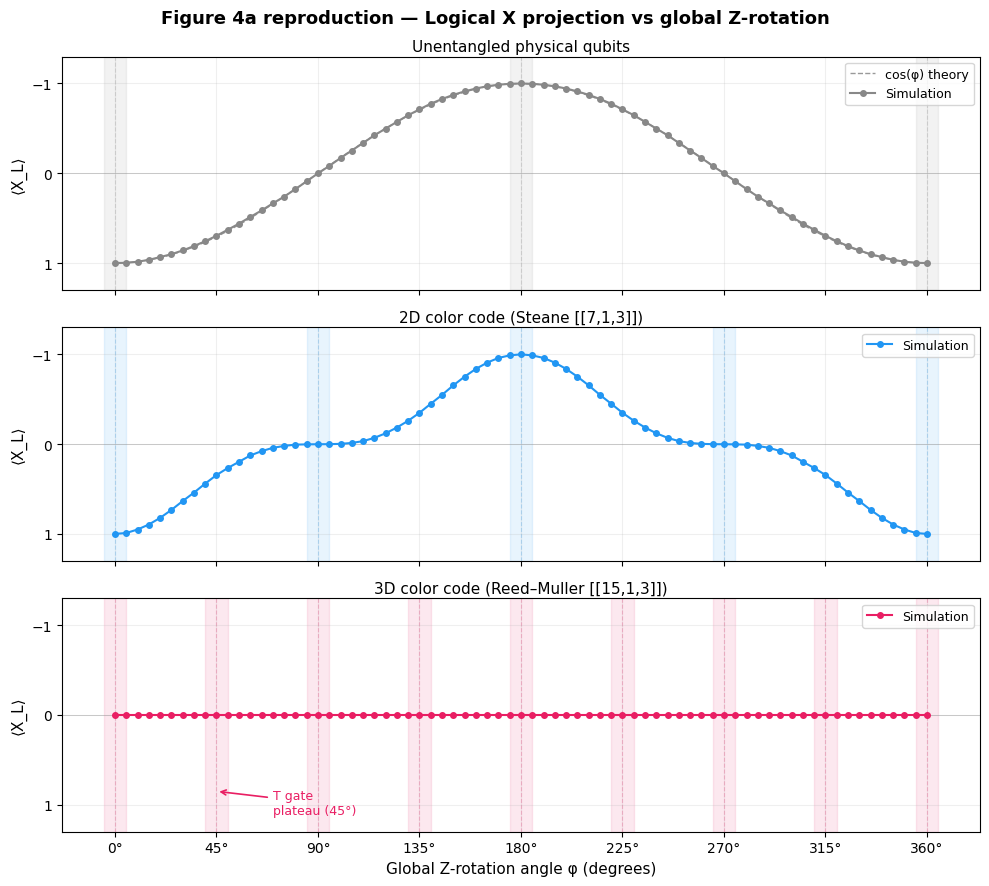

In [16]:
# @title Plot — reproducing Figure 4a style

phis_deg = np.degrees(phis)
theory_unentangled = np.cos(phis)

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
fig.suptitle("Figure 4a reproduction — Logical X projection vs global Z-rotation",
             fontsize=13, fontweight='bold')

plateau_colors = dict(alpha=0.12)
configs = [
    (axes[0], results_unentangled, theory_unentangled, "Unentangled physical qubits",
     [0, 180, 360], "#888888"),
    (axes[1], results_steane, None, "2D color code (Steane [[7,1,3]])",
     [0, 90, 180, 270, 360], "#2196F3"),
    (axes[2], results_rm, None, "3D color code (Reed–Muller [[15,1,3]])",
     [0, 45, 90, 135, 180, 225, 270, 315, 360], "#E91E63"),
]

for ax, data, theory, title, plateau_angles, color in configs:
    # Shade plateau regions
    for pa in plateau_angles:
        ax.axvspan(pa - 5, pa + 5, color=color, alpha=0.10, zorder=0)
        ax.axvline(pa, color=color, alpha=0.3, linewidth=0.8, linestyle='--', zorder=1)

    # Theory curve for unentangled
    if theory is not None:
        ax.plot(phis_deg, theory, 'k--', linewidth=1, alpha=0.4, label='cos(φ) theory')

    # Simulated data
    ax.plot(phis_deg, data, 'o-', color=color, markersize=4, linewidth=1.5,
            label='Simulation', zorder=5)

    ax.set_ylabel("⟨X_L⟩", fontsize=11)
    ax.set_ylim(-1.3, 1.3)
    ax.invert_yaxis()  # Inverts the Y-axis for each chart
    ax.set_title(title, fontsize=11, pad=4)
    ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.2)
    ax.set_yticks([-1, 0, 1])

# Annotate the 45° plateau on the RM plot specifically
ax_rm = axes[2]
ax_rm.annotate('T gate\nplateau (45°)',
               xy=(45, 0.85), xytext=(70, 1.1),
               fontsize=9, color='#E91E63',
               arrowprops=dict(arrowstyle='->', color='#E91E63', lw=1.2))

axes[2].set_xlabel("Global Z-rotation angle φ (degrees)", fontsize=11)
xticks = list(range(0, 361, 45))
axes[2].set_xticks(xticks)
axes[2].set_xticklabels([f"{x}°" for x in xticks])

plt.tight_layout()
plt.show()

## Foreword
This notebook reproduces in TSIM some of the finding of this article towards fault-tolerant universal computation achieved by the combination of the following error correction techniques
```
Steane code (2D)          →  transversal H, S, CNOT   (Clifford)
Reed-Muller code (3D)     →  transversal T            (non-Clifford)
Solovay-Kitaev theorem    →  H + T = any rotation
Gate teleportation        →  glues them together fault-tolerantly
Eastin-Knill              →  bypassed via measurement
```

## References
*Bluvstein, D., Geim, A.A., Li, S.H. et al. *

[A fault-tolerant neutral-atom architecture for universal quantum computation. ](https://doi.org/10.1038/s41586-025-09848-5)

*Nature 649, 39–46 (2026)*


---



### TSIM
```
@article{tsim2026,
  title={Tsim: Fast Universal Simulator for Quantum Error Correction},
  author={Haenel, Rafael and Luo, Xiuzhe and Zhao, Chen},
  journal={arXiv preprint arXiv:2604.01059},
  year={2026}
}
```

